## The State of Tax Justice: Impute Missing Data
### TO DO: Deal with "rest of the world"
- Author: Alison Schultz, based on Javier Garcia Bernado's work
- Created: 20 August 2023
- Last updated: 23 September 2024

**Description**
- This notebook is one out of three notebooks to estimate the tax losses caused by profit shifting by multinational enterprises (MNEs). The analysis uses the misalignment method based on the country-by-country reports (CbCR) published by the OECD.
- This notebook uses the extended CBCR dataset "data/intermediate/cbcr_imputation_sample.csv" created in the notebook "1_clean" and performs multiple impuration to replace missing values of country by country reporting data, mimicking a dataset of global MNE activity. It results in the notebook "data/final/cbcr_main.csv" that includes many datasets in which variables are imputed such that (i) variables from aggregated reporting done by some jurisdictions (e.g. per continent) are attributed to specific countries and (ii) global MNE activity from non-reporting countries is estimated. For details on the imputation process, see Appendix A1 in Garcia Bernardo/Janský (2024) that can be accessed here: https://www.sciencedirect.com/science/article/pii/S0305750X23003455, the working paper version is here: https://www.econstor.eu/bitstream/10419/286362/1/wp-2023-33.pdf 
- The notebook also generates descriptives to assess the imputation success.

**Outline**
1. 

**To dos before running this notebook**
- Run notebook 1_clean. Note the requirements and instructions given in that notebook.

### 0. Load packages

In [ ]:
pip install joblib

In [53]:
import pandas as pd
import numpy as np
from config import *
import tjn_tools
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from itertools import permutations, product
from sklearn.metrics import r2_score,make_scorer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LassoCV, Lasso, LinearRegression, BayesianRidge
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.model_selection import cross_validate, train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from sklearn.inspection import permutation_importance
from joblib import Parallel, delayed

### 1. Import data
- The imputation procedure relies on two datasets: First, cbcr_imputation_sample that includes the actual country by country reporting data from the OECD and all kinds of unilateral and bilateral variables that can be helpful to estimate missings in the actual OECD data. Second, cbcr_sample that only includes data that is actually reported for all subgroups of MNEs (i.e. aggregating both the ones that make profits and the ones that make losses).

In [54]:
cbcr_imputation_sample = pd.read_csv(f'{data_intermediate}/cbcr_imputation_sample.csv')
cbcr_sample = pd.read_csv(f'{data_intermediate}/cbcr_main_no_imputation_allsubgroupsonly.csv')

Some specific data cleaning that is only needed for the imputation process

In [55]:
# Correct mistake in Argentinian data
cbcr_imputation_sample.loc[
    (cbcr_imputation_sample['iso_parent'] == "ARG") & 
    (cbcr_imputation_sample['iso_partner'] == "S") & 
    (cbcr_imputation_sample['year'] == 2019), 
    'partner_iso'
] = 'S_O'

# "Rest of the world" is mainly defined as "WXD", but partly as "W_O".
cbcr_imputation_sample.loc[
    (cbcr_imputation_sample['iso_partner'] == "W_O"), 
    'partner_iso'
] = 'WXD'

Define target variables, i.e. the variables to be imputed. These are all variables that are or could be relevant to estimate misalignment

In [56]:
target_variables = ["ln_profit_loss_before_income_tax_corrected",
    "ln_n_employees",
    "ln_unrelated_party_revenues",
    "ln_tangible_assets_except_cash",
    'ln_stated_capital',
    'ln_total_revenues',
    'ln_related_party_revenues',
    'ln_holding_or_managing_ip']

### 2. Impute domestic values
- Domestic values are the values that a country reports about itself, e.g. the US activities of US based MNEs. We have to impute these values for all non-reporting countries

#### 2.1 Define imputation procedure for domestic values
- The following section imputes domestic variables, i.e. variables for which the reporting country (iso_parent) is the same as the partner country (iso_partner). These values are missing only for non-reporting countries, as all reporting countries specify the difference between domestic and foreign activity, even though they might not disaggregate foreign activity adequately.
- We estimate the number of domestic employees, revenue and tangible assets for all non-reporting countries. We do so by using a linear model based on the number of expected companies in each country (from Orbis), its GDP (from the Worldbank), population (from the Worldbank), the average ETRs (calculated in the notebook 1_clean) and the total consolidated banking claims on an immediate counterparty basis (from BIS). 



In [57]:
predictor_variables_domestic = ["ln_gdp_current_usd_partner", "ln_population_partner", "etr_foreign_corrected_partner", 
                             "cit_partner", "ln_n_companies_orbis", "ln_turnover_orbis", "ln_n_employees_orbis", 
                             "ln_wage_monthly_partner", "ln_bank_claims_total_partner",'cthi_2021_share_partner','cthi_2021_score_parent']

In [58]:
def predict_domestic_values(domestic_imputation_sample, variables_to_predict=target_variables, predictor_columns=predictor_variables_domestic):
    """
    This function imputes missing values for specified domestic variables using a linear regression model 
    based on a set of predictor variables. The function allows the user to specify both the variables to 
    predict (e.g., profits, employees, revenues) and the predictors (e.g., GDP, population, ETR, bank claims).

    Parameters:
    - domestic_imputation_sample: DataFrame containing the data to be used for imputation.
    - variables_to_predict: List of variables to predict (logged). Defaults to ['ln_profit_loss_before_income_tax_corrected', 
      'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash'].
    - predictor_columns: List of predictor variables to use in the regression model. Defaults to 
      ["ln_gdp_current_usd_partner", "ln_population_partner", "etr_foreign_corrected_partner", 
                             "cit_partner", "ln_n_companies_orbis", "ln_turnover_orbis", "ln_n_employees_orbis", 
                             "ln_wage_monthly_partner", "ln_bank_claims_total_partner",'cthi_2021_share','cthi_2021_score']

    Returns:
    - DataFrame with original and imputed values for the specified variables.
    """
    
    # Initialize the imputer (using median strategy)
    imputer = SimpleImputer(strategy='median')

    for var in variables_to_predict:
        clf = LinearRegression()
        
        # Prepare the dataset
        df = domestic_imputation_sample[
            domestic_imputation_sample['year'].between(first_year, first_year + n_years - 1)
        ].copy()
        
        # Ensure target variable is not missing
        df = df.dropna(subset=[var])
        
        # Filter rows where ln_n_companies_orbis > 0
        df = df[df["ln_n_companies_orbis"] > 0]
        
        # Extract predictors and target variable
        X = df[predictor_columns]
        y = df[var].values

        # Impute missing values in predictors for training data
        X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=predictor_columns, index=X.index)
        
        # Check if there are any samples left
        if X_imputed.shape[0] == 0:
            print(f"Skipping '{var}' because no valid samples are available for training (after imputing).")
            continue
        
        # Fit the model
        clf.fit(X_imputed, y)
        
        # Impute missing values in the predictors for the entire dataset
        X_full = domestic_imputation_sample[predictor_columns]
        X_full_imputed = pd.DataFrame(imputer.transform(X_full), columns=predictor_columns, index=X_full.index)

        # Predict for all rows and store in 'fitted_ln_variable'
        domestic_imputation_sample[f"fitted_{var}"] = clf.predict(X_full_imputed)
        
        # Set predicted value to 0 where ln_n_companies_orbis == 0
        domestic_imputation_sample.loc[
            domestic_imputation_sample["ln_n_companies_orbis"] == 0, f"fitted_{var}"
        ] = 0
        
        # Convert predictions back to original scale and store in 'fitted_variable'
        non_log_var = var[3:]  # Remove 'ln_' prefix to get the non-logged variable name
        domestic_imputation_sample[f"fitted_{non_log_var}"] = np.exp(domestic_imputation_sample[f"fitted_{var}"]) - 1

    # Set 'iso_partner' equal to 'iso_parent' (as imputation is done for domestic values)
    domestic_imputation_sample["iso_partner"] = domestic_imputation_sample["iso_parent"]
    
    return domestic_imputation_sample

#### 2.2 Evaluate domestic imputation success
TO DO: Think about equalizing imputation method with foreign values and try to improve prediction for profits

In [59]:
def evaluate_domestic_prediction(domestic_imputation_sample, variables_to_predict=target_variables, predictor_columns=predictor_variables_domestic):
    """
    Evaluates regression models by calculating in-sample and out-of-sample R^2 and plotting fitted vs. actual values.
    
    Parameters:
    - domestic_imputation_sample: DataFrame containing the data.
    - variables_to_predict: List of target variables (logged). Defaults to the same as in predict_domestic_values().
    - predictor_columns: List of predictor variables. Defaults to the same as in predict_domestic_values().
    """

    # Initialize the imputer (using median strategy)
    imputer = SimpleImputer(strategy='median')

    # Dictionary to store R^2 scores
    r2_scores = {}

    for var in variables_to_predict:
        # Prepare the dataset
        df = domestic_imputation_sample[
            domestic_imputation_sample['year'].between(first_year, first_year + n_years - 1)
        ].copy()

        # Ensure target variable is not missing
        df = df.dropna(subset=[var])

        # Filter rows where ln_n_companies_orbis > 0
        df = df[df["ln_n_companies_orbis"] > 0]

        # Extract predictors and target variable
        X = df[predictor_columns]
        y = df[var].values

        # Impute missing values in predictors for training data
        X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=predictor_columns, index=X.index)

        # Check if there are any samples left
        if X_imputed.shape[0] == 0:
            print(f"Skipping '{var}' because no valid samples are available for training (after imputing).")
            continue

        # Split data into training and test sets
        X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

        # Fit the model
        clf = LinearRegression()
        clf.fit(X_train, y_train)

        # Predict on training and test data
        y_train_pred = clf.predict(X_train)
        y_test_pred = clf.predict(X_test)

        # Calculate R^2 scores
        r2_train = r2_score(y_train, y_train_pred)
        r2_test = r2_score(y_test, y_test_pred)

        # Store R^2 scores
        r2_scores[var] = {'R2_train': r2_train, 'R2_test': r2_test}

        # Plotting the fitted vs. actual values for training data
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=y_train, y=y_train_pred, alpha=0.7)
        plt.title(f"Fitted vs. Actual Values for {var} (Training Data)")
        plt.xlabel("Actual Values")
        plt.ylabel("Fitted Values")
        plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
        plt.show()

        # Plotting the fitted vs. actual values for test data
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=y_test, y=y_test_pred, color='orange', alpha=0.7)
        plt.title(f"Fitted vs. Actual Values for {var} (Test Data)")
        plt.xlabel("Actual Values")
        plt.ylabel("Fitted Values")
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
        plt.show()

        print(f"Variable: {var}")
        print(f"In-sample R^2 (Training): {r2_train:.4f}")
        print(f"Out-of-sample R^2 (Test): {r2_test:.4f}")
        print("-" * 40)

    return r2_scores

Define domestic imputation sample to apply the evaluation

In [60]:
domestic_imputation_sample = cbcr_imputation_sample.loc[cbcr_imputation_sample["iso_parent"] == cbcr_imputation_sample["iso_partner"]]

Run evaluation

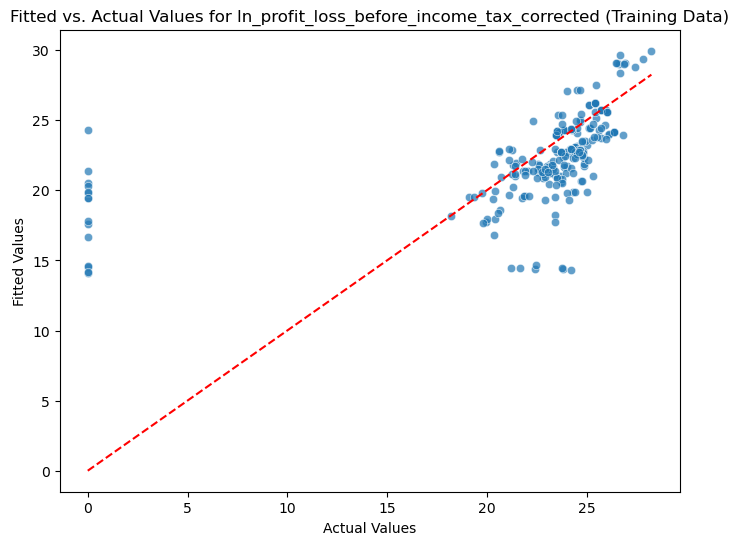

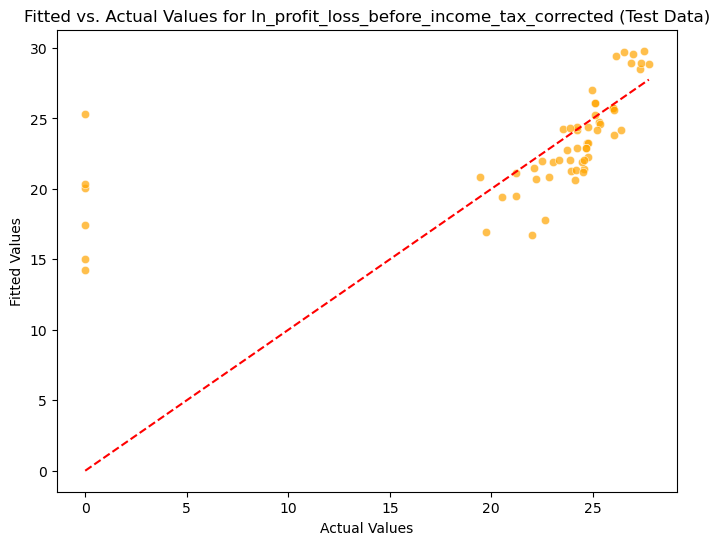

Variable: ln_profit_loss_before_income_tax_corrected
In-sample R^2 (Training): 0.2511
Out-of-sample R^2 (Test): 0.2925
----------------------------------------


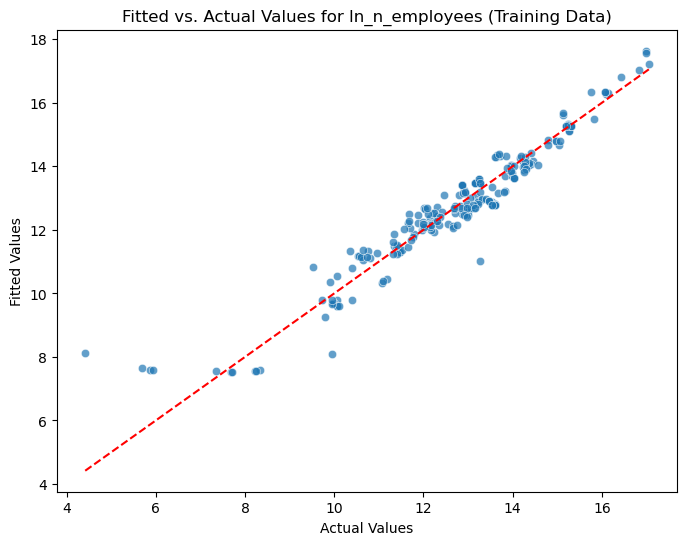

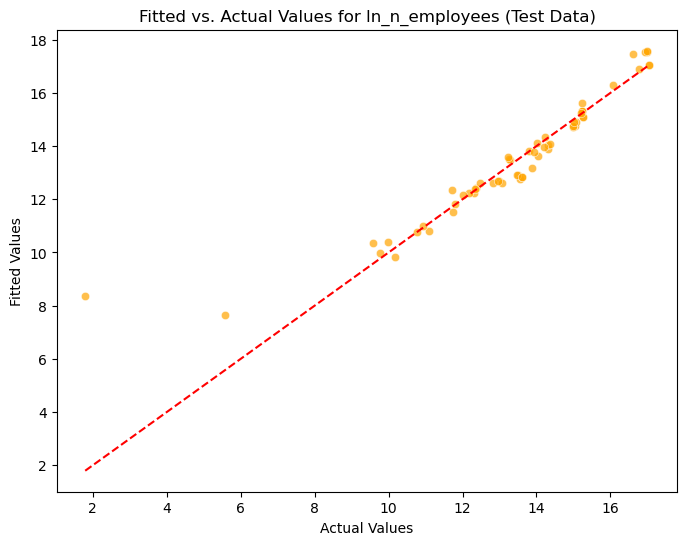

Variable: ln_n_employees
In-sample R^2 (Training): 0.9252
Out-of-sample R^2 (Test): 0.8668
----------------------------------------


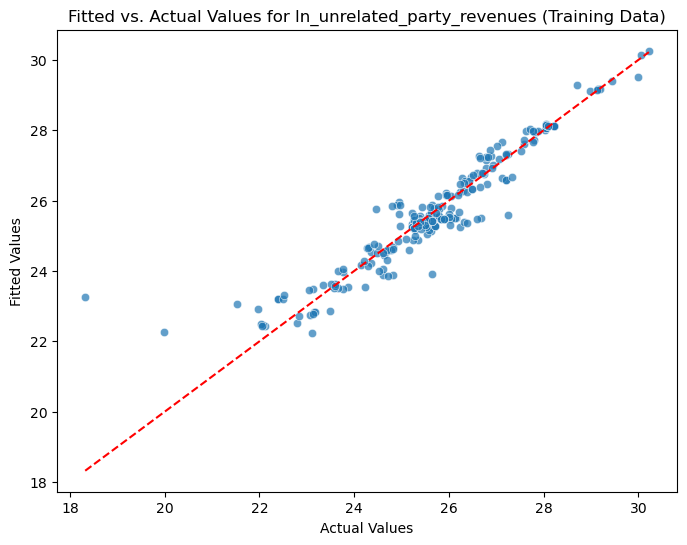

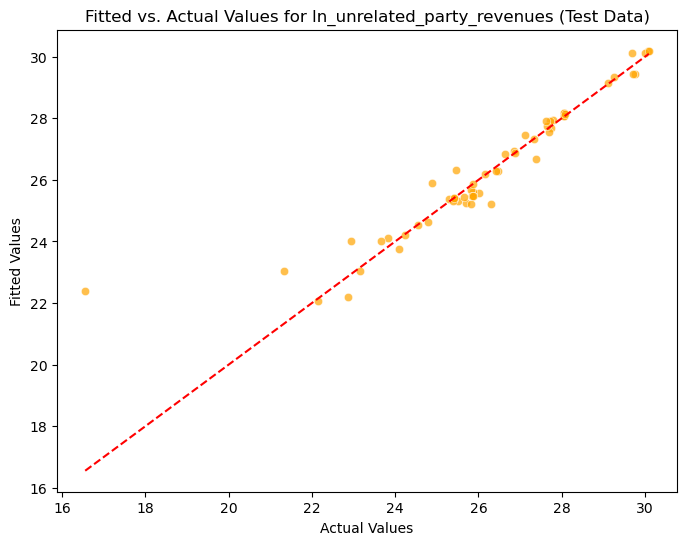

Variable: ln_unrelated_party_revenues
In-sample R^2 (Training): 0.8963
Out-of-sample R^2 (Test): 0.8664
----------------------------------------


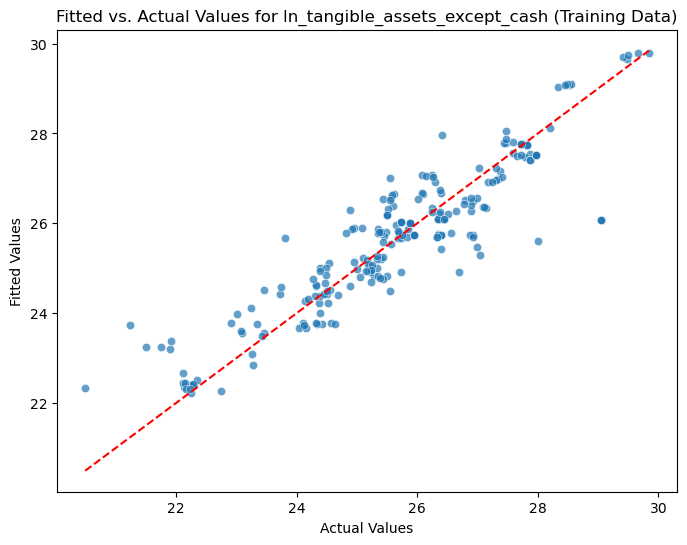

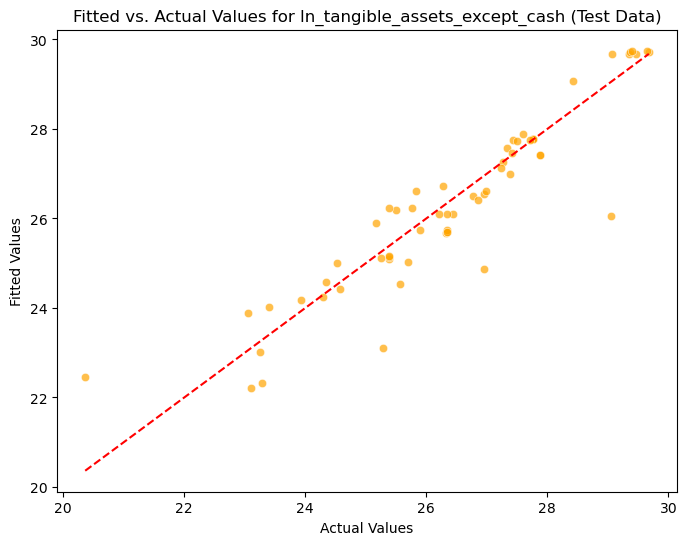

Variable: ln_tangible_assets_except_cash
In-sample R^2 (Training): 0.8264
Out-of-sample R^2 (Test): 0.8405
----------------------------------------


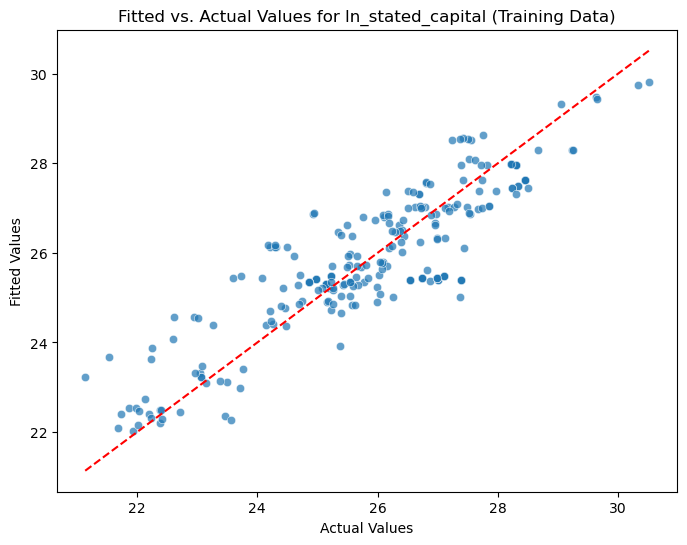

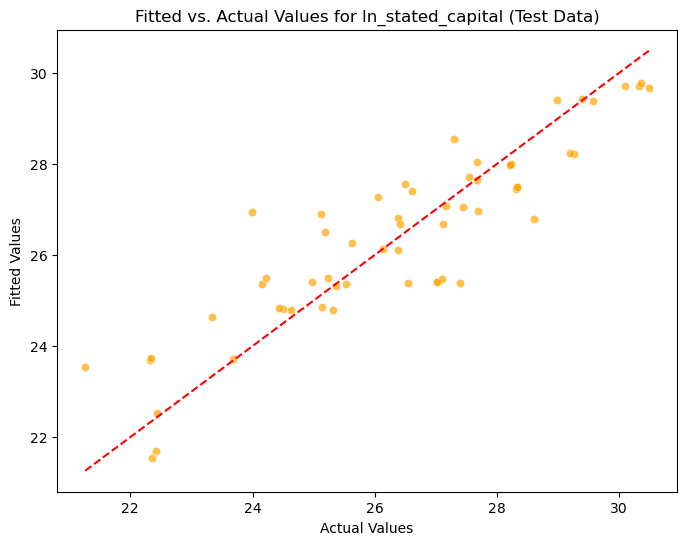

Variable: ln_stated_capital
In-sample R^2 (Training): 0.7781
Out-of-sample R^2 (Test): 0.8086
----------------------------------------


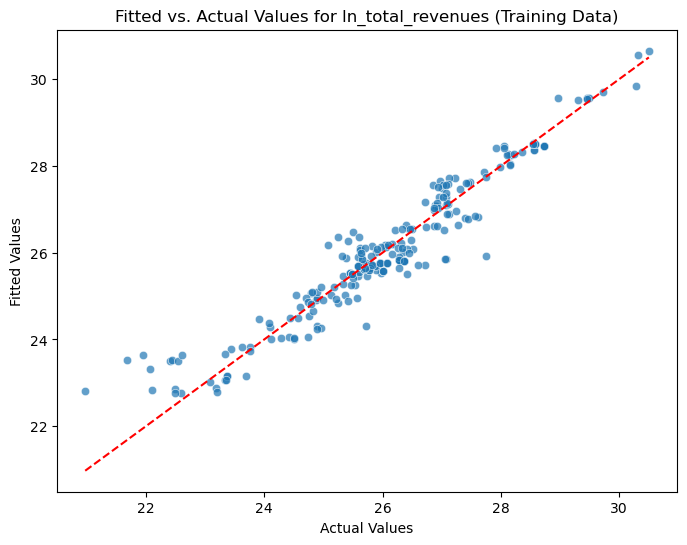

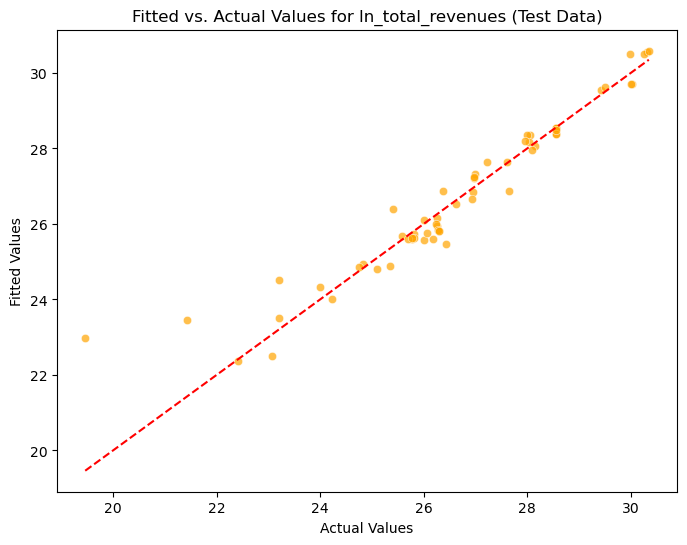

Variable: ln_total_revenues
In-sample R^2 (Training): 0.9216
Out-of-sample R^2 (Test): 0.9146
----------------------------------------


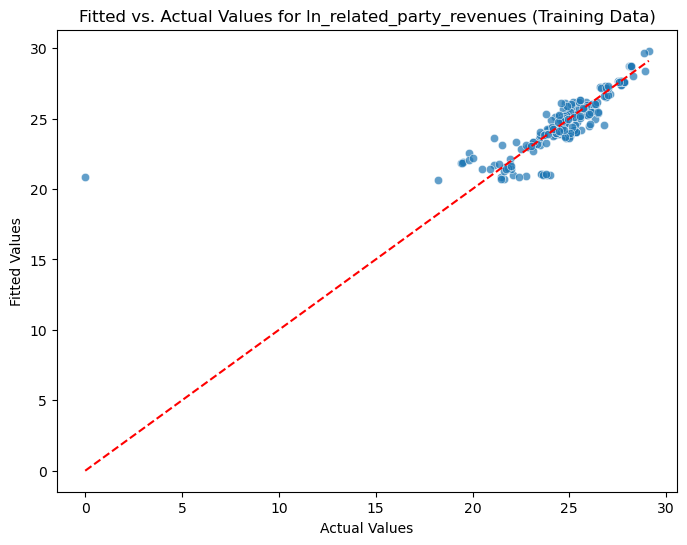

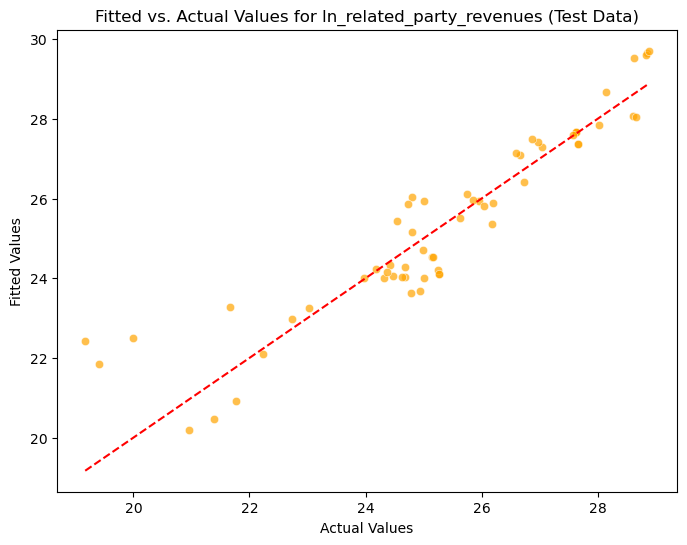

Variable: ln_related_party_revenues
In-sample R^2 (Training): 0.5793
Out-of-sample R^2 (Test): 0.8524
----------------------------------------


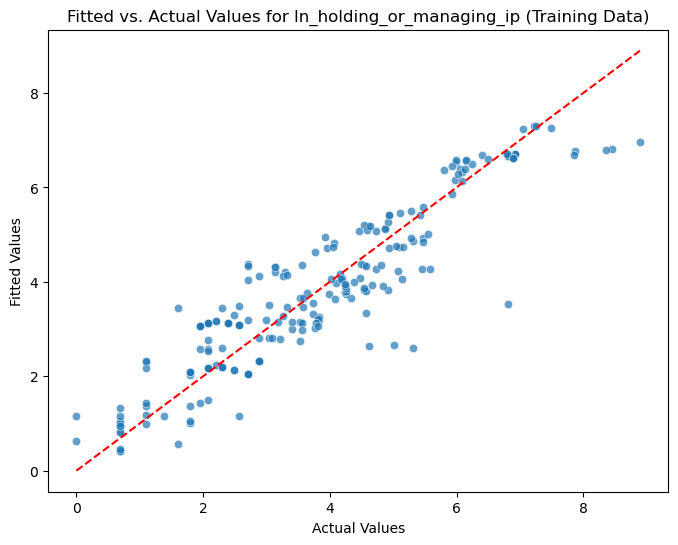

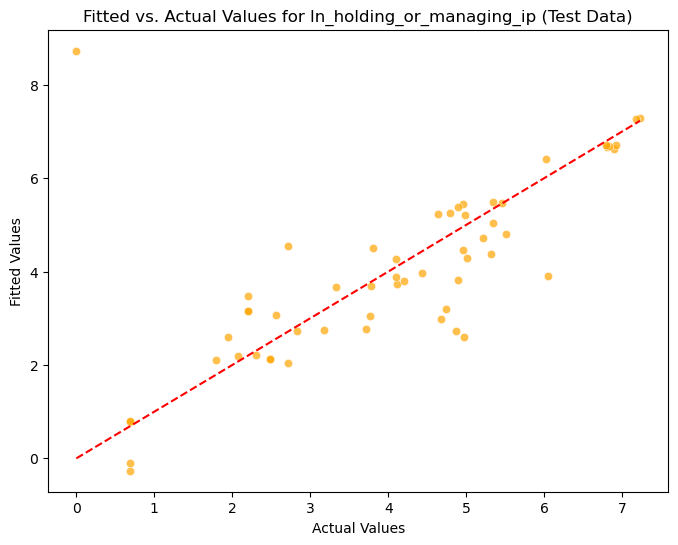

Variable: ln_holding_or_managing_ip
In-sample R^2 (Training): 0.8464
Out-of-sample R^2 (Test): 0.3923
----------------------------------------


In [61]:
evaluate_domestic_imputation = evaluate_domestic_prediction(domestic_imputation_sample)

### 3. Impute foreign values
- These are the values for all combinations of reporting country (iso_parent) and partner country (iso_partner) for which:
    - the parent country is not reporting on an actual country by country but on an aggregate basis, or
    - the parent country is not reporting at all.

#### 3.1 Define metaparameters for imputation

Create foreign imputation sample to define metaparameters

In [62]:
foreign_imputation_sample = cbcr_imputation_sample.loc[cbcr_imputation_sample["iso_parent"] != cbcr_imputation_sample["iso_partner"]]
true_values = cbcr_sample[["iso_parent","iso_partner","year",'income_tax_paid_on_cash_basis','profit_loss_before_income_tax_corrected',
'n_employees',"unrelated_party_revenues","tangible_assets_except_cash",'stated_capital','total_revenues','related_party_revenues','holding_or_managing_ip']]

In [63]:
scorer = make_scorer(r2_score)

In [64]:
def find_best_model(est,clf,df):
        
    for var in ["ln_profit_loss_before_income_tax_corrected",
    "ln_n_employees",
    "ln_unrelated_party_revenues",
    "ln_tangible_assets_except_cash",
    'ln_stated_capital',
    'ln_total_revenues',
    'ln_related_party_revenues',
    'ln_holding_or_managing_ip']:
        df = cbcr_sample.copy().dropna(subset=["ln_profit_loss_before_income_tax_corrected",var])
        df[var].replace([np.inf, -np.inf], np.nan, inplace=True)
        print(var)
        y = df[var].values
        a = df.drop(columns=["income_tax_paid_on_cash_basis","ln_profit_loss_before_income_tax_corrected","ln_n_employees","ln_unrelated_party_revenues",
            "ln_tangible_assets_except_cash",'ln_stated_capital','ln_total_revenues','ln_related_party_revenues','ln_holding_or_managing_ip']
            +[_ for _ in df.columns if "fitted" in _]+[_ for _ in df.columns if "month_wage" in _])
        columns = np.array(a.columns)[a.dtypes!=object]
        X = df[columns].values
        print(y.min(),y.mean(),y.max(),y.std())


        search = clf.fit(X,y)
        print(var, search.best_params_)
        try:
            plt.plot(search.param_grid["alpha"],search.cv_results_["mean_test_score"])
            plt.show()
        except:
            pass            

The following code block only has to be ran once to determine the meta parameters. If you want to run it, delete the "if 0:"

In [65]:
if 0:
    distributions = dict(learning_rate=np.linspace(0.01,0.2,7),
                        l2_regularization=np.logspace(1,3,11),
                        min_samples_leaf=[20],)
    est = HistGradientBoostingRegressor(random_state=0)

    clf = GridSearchCV(est, distributions, n_jobs=-1, cv=5,verbose=5, scoring=scorer)

    find_best_model(est,clf,foreign_imputation_sample.dropna(subset=["ln_profit_loss_before_income_tax_corrected"]))

In [66]:
# Set identified parameters
metaparameters  = {
    "ln_profit_loss_before_income_tax_corrected": {'l2_regularization': 63.09573444801933, 'learning_rate': 0.2, 'min_samples_leaf': 20},
    "ln_n_employees": {'l2_regularization': 39.810717055349734, 'learning_rate': 0.07333333333333333, 'min_samples_leaf': 20},
    "ln_unrelated_party_revenues": {'l2_regularization': 15.848931924611133, 'learning_rate': 0.105, 'min_samples_leaf': 20},
    "ln_tangible_assets_except_cash": {'l2_regularization': 39.810717055349734, 'learning_rate': 0.2, 'min_samples_leaf': 20},
    'ln_stated_capital': {'l2_regularization': 25.118864315095795, 'learning_rate': 0.07333333333333333, 'min_samples_leaf': 20},
    'ln_total_revenues': {'l2_regularization': 10.0, 'learning_rate': 0.105, 'min_samples_leaf': 20},
    'ln_related_party_revenues': {'l2_regularization': 39.810717055349734, 'learning_rate': 0.1366666666666667, 'min_samples_leaf': 20},
    'ln_holding_or_managing_ip': {'l2_regularization': 39.810717055349734, 'learning_rate': 0.1366666666666667, 'min_samples_leaf': 20}, #the last two rows are actually the same in the previously ran find_best_model() function
}

#### 3.2 Define imputation procedure for foreign values

Define predictor variables (target variables are the same as for the domestic imputation)

In [67]:
predictor_variables_foreign = ['etr_domestic_corrected_partner', 
                               'etr_foreign_corrected_partner', 
                               'etr_average_corrected_partner',
                               'cit_partner',
                               'population_partner',
                               'ln_wage_monthly_partner',
                               'ln_gdp_current_usd_partner',
                               'ln_gvt_health_expenditure_partner',
                               'ukt_partner',
                               'oecd_partner',
                               'nld_oct_partner',
                               'eu_partner',
                               'etr_domestic_corrected_parent', 
                               'etr_foreign_corrected_parent', 
                               'etr_average_corrected_parent',
                               'cit_parent',
                               'population_parent',
                               'ln_wage_monthly_parent',
                               'ln_gdp_current_usd_parent',
                               'ln_gvt_health_expenditure_parent',
                               'ukt_parent',
                               'oecd_parent',
                               'nld_oct_parent',
                               'eu_parent',
                               'ln_exports_tot',
                               'ln_imports_tot',
                               'ln_fdi_inward',
                               'ln_fdi_outward',
                               'ln_pi_inward',
                               'ln_pi_outward',
                               'ln_claims',
                               'ln_liabilities',
                               'ln_bank_claims_total_partner',
                               'ln_bank_claims_total_parent',
                               'distw_arithmetic',
                               'transition_legalchange',
                               'col45',
                               'col_dep_ever',
                               'comcol',
                               'comlang_ethno',
                               'comlang_off',
                               'comleg_posttrans',
                               'comleg_pretrans',
                               'comrelig',
                               'contig',
                               'sibling',
                               'fta_wto',
                               'r_heg',
                               'p_heg',
                               'r_entry_proc',
                               'p_entry_proc',
                               'r_entry_time',
                               'p_entry_time',
                               'r_entry_tp',
                               'p_entry_tp',
                               'r_entry_cost',
                               'p_entry_cost',
                               'r_gatt',
                               'p_gatt',
                               'both_eu',
                               'same_region',
                               'both_ukt',
                               'both_oecd',
                               'ln_n_companies_orbis',
                               'ln_n_employees_orbis',
                               'ln_turnover_orbis'
        ]

Define function to predict foreign values

In [68]:
def predict_foreign_values(foreign_imputation_sample, metaparameters=metaparameters, target_variables=target_variables, predictor_variables=predictor_variables_foreign):
    """
    Predicts foreign values using HistGradientBoostingRegressor with specified metaparameters.

    Parameters:
    - foreign_imputation_sample: DataFrame containing the data.
    - metaparameters: Dictionary containing hyperparameters for each target variable.
    - target_variables: List of target variables to predict (logged variables). Defaults are defined within the function.
    - predictor_variables: List of predictor variables. Defaults are defined within the function.

    Returns:
    - DataFrame with predicted values for the specified variables, including both logged ('fitted_ln_') and 
      non-logged ('fitted_') versions, while keeping the original variables unchanged.
    """

    # Copy the dataset to avoid modifying the original
    data = foreign_imputation_sample.copy()

    # Loop over each target variable to predict
    for var in target_variables:
        print(f"Predicting values for: {var}")

        # Check if the target variable exists in the data
        if var not in data.columns:
            print(f"Target variable '{var}' not found in the data. Skipping...")
            continue

        # Create a training dataset: rows where the target variable is not missing
        train_df = data.dropna(subset=[var])

        # Ensure predictor variables exist in the data
        available_predictors = [col for col in predictor_variables if col in data.columns]

        # Check if there are sufficient predictors
        if len(available_predictors) == 0:
            print(f"No available predictors for variable '{var}'. Skipping...")
            continue

        # Extract predictors (X) and target (y)
        X_train = train_df[available_predictors]
        y_train = train_df[var]

        # Retrieve metaparameters for the current variable
        params = metaparameters.get(var, {})
        if not params:
            print(f"No metaparameters found for variable '{var}'. Using default parameters.")

        # Initialize the model with metaparameters (if available)
        clf = HistGradientBoostingRegressor(
            max_iter=100,
            random_state=42,
            **params  # Unpack the metaparameters
        )

        # Fit the model on the training data
        clf.fit(X_train, y_train)

        # Predict on the entire dataset (including rows with missing target variable)
        X_full = data[available_predictors]

        # Since HistGradientBoostingRegressor handles missing values natively, we don't need to impute missing values in X_full

        # Predict the target variable (logged values) for all rows
        y_pred_logged = clf.predict(X_full)

        # Store the predicted logged values in a new column with prefix 'fitted_ln_'
        data[f"fitted_{var}"] = y_pred_logged

        # Remove 'ln_' prefix to get the non-logged variable name
        non_log_var = var[3:]

        # Exponentiate the predicted logged values to get predicted non-logged values
        y_pred_non_logged = np.exp(y_pred_logged)

        # Store the predicted non-logged values in a new column with prefix 'fitted_'
        data[f"fitted_{non_log_var}"] = y_pred_non_logged

    # Return the dataset with the new 'fitted_' columns
    return data


#### 3.3 Check imputation success for foreign variables

In [69]:
def evaluate_foreign_predictions(data, metaparameters, target_variables=target_variables, predictor_variables=predictor_variables_foreign, test_size=0.2, random_state=42):
    """
    Evaluates the predictions by calculating in-sample and out-of-sample R² and plotting fitted vs. actual values.

    Parameters:
    - data: DataFrame containing the data with original variables.
    - metaparameters: Dictionary containing hyperparameters for each target variable.
    - target_variables: List of target variables to be predicted.
    - predictor_variables: List of predictor variables.
    - test_size: Proportion of the dataset to include in the test split.
    - random_state: Random seed for reproducibility.

    Returns:
    - Dictionary of R² scores for each variable.
    """
    from sklearn.experimental import enable_hist_gradient_boosting  # noqa
    from sklearn.ensemble import HistGradientBoostingRegressor

    # Copy the data to avoid modifying the original
    data = data.copy()

    r2_scores = {}

    for var in target_variables:
        print(f"Processing variable: {var}")

        # Check if the target variable exists in the data
        if var not in data.columns:
            print(f"Target variable '{var}' not found in the data. Skipping...")
            continue

        # Create a dataset: rows where the target variable is not missing
        df = data.dropna(subset=[var])

        # Ensure predictor variables exist in the data
        available_predictors = [col for col in predictor_variables if col in df.columns]

        # Check if there are sufficient predictors
        if len(available_predictors) == 0:
            print(f"No available predictors for variable '{var}'. Skipping...")
            continue

        # Extract predictors (X) and target (y)
        X = df[available_predictors]
        y = df[var]

        # Split the data into training and test sets
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

        # Retrieve metaparameters for the current variable
        params = metaparameters.get(var, {})
        if not params:
            print(f"No metaparameters found for variable '{var}'. Using default parameters.")

        # Initialize the model with metaparameters
        clf = HistGradientBoostingRegressor(
            max_iter=100,
            random_state=random_state,
            **params  # Unpack the metaparameters
        )

        # Fit the model on the training data
        clf.fit(X_train, y_train)

        # Predict on training data (in-sample)
        y_train_pred = clf.predict(X_train)

        # Predict on test data (out-of-sample)
        y_test_pred = clf.predict(X_test)

        # Calculate R² scores
        r2_train = r2_score(y_train, y_train_pred)
        r2_test = r2_score(y_test, y_test_pred)

        r2_scores[var] = {'R2_train': r2_train, 'R2_test': r2_test}

        # Plotting the fitted vs. actual values for training data
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=y_train, y=y_train_pred, alpha=0.7)
        plt.title(f"Fitted vs. Actual Values for {var} (Training Data)")
        plt.xlabel("Actual Values")
        plt.ylabel("Predicted Values")
        plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
        plt.show()

        # Plotting the fitted vs. actual values for test data
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=y_test, y=y_test_pred, color='orange', alpha=0.7)
        plt.title(f"Fitted vs. Actual Values for {var} (Test Data)")
        plt.xlabel("Actual Values")
        plt.ylabel("Predicted Values")
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
        plt.show()

        print(f"Variable: {var}")
        print(f"In-sample R² (Training): {r2_train:.4f}")
        print(f"Out-of-sample R² (Test): {r2_test:.4f}")
        print("-" * 40)

    return r2_scores

Run function to be able to evaluate its effectiveness

In [70]:
filled_foreign_data = predict_foreign_values(foreign_imputation_sample,metaparameters)

Predicting values for: ln_profit_loss_before_income_tax_corrected
Predicting values for: ln_n_employees
Predicting values for: ln_unrelated_party_revenues
Predicting values for: ln_tangible_assets_except_cash
Predicting values for: ln_stated_capital
Predicting values for: ln_total_revenues
Predicting values for: ln_related_party_revenues
Predicting values for: ln_holding_or_managing_ip


Evaluate effectiveness of prediction

Processing variable: ln_profit_loss_before_income_tax_corrected


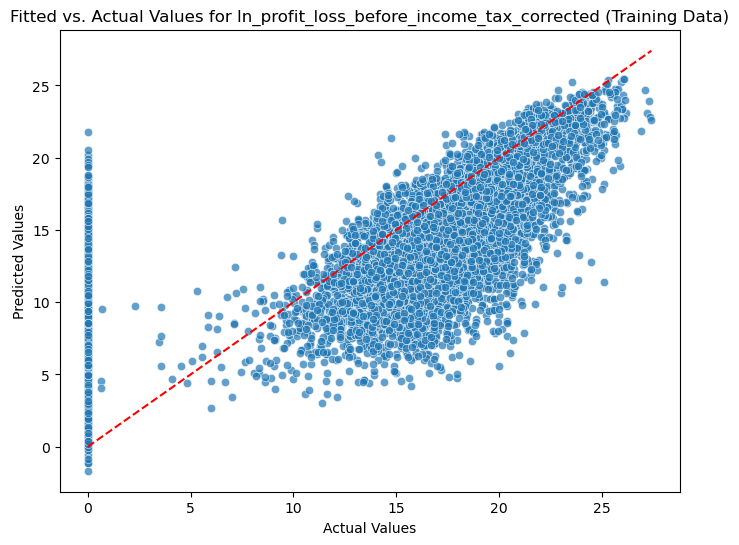

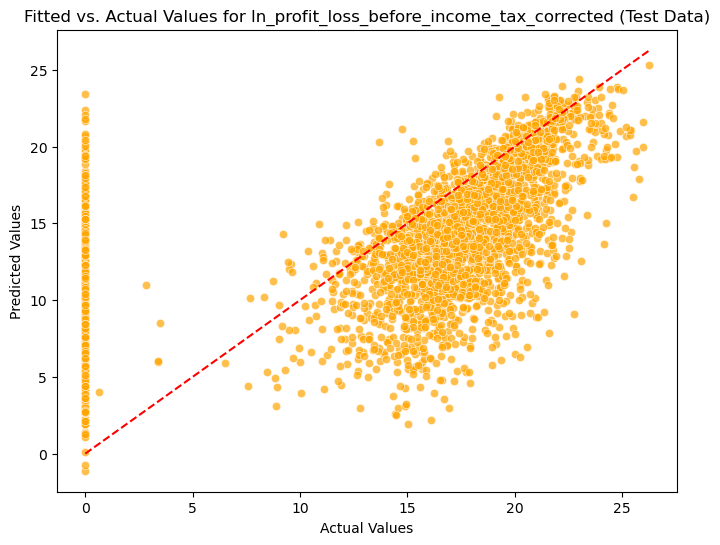

Variable: ln_profit_loss_before_income_tax_corrected
In-sample R² (Training): 0.5573
Out-of-sample R² (Test): 0.3285
----------------------------------------
Processing variable: ln_n_employees


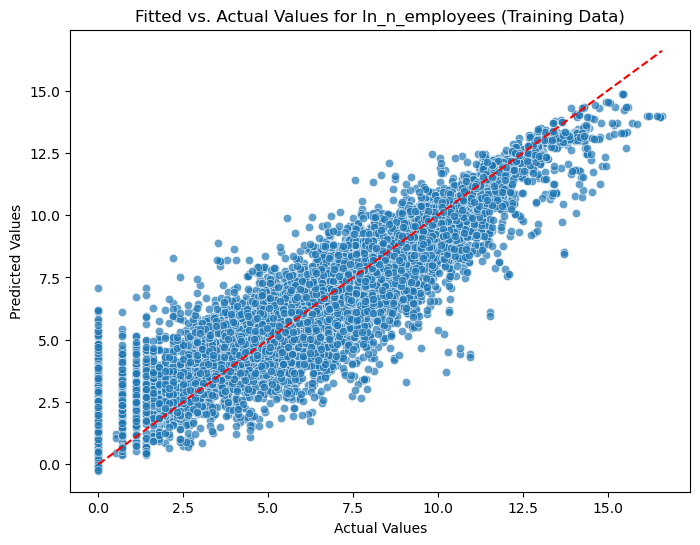

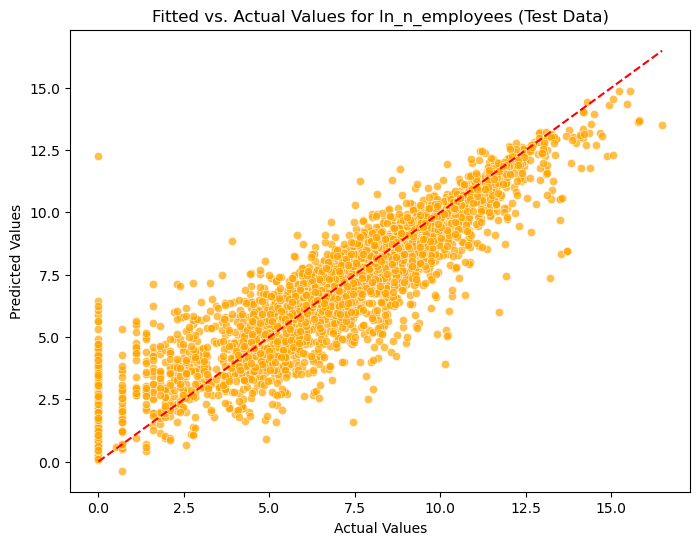

Variable: ln_n_employees
In-sample R² (Training): 0.8484
Out-of-sample R² (Test): 0.8077
----------------------------------------
Processing variable: ln_unrelated_party_revenues


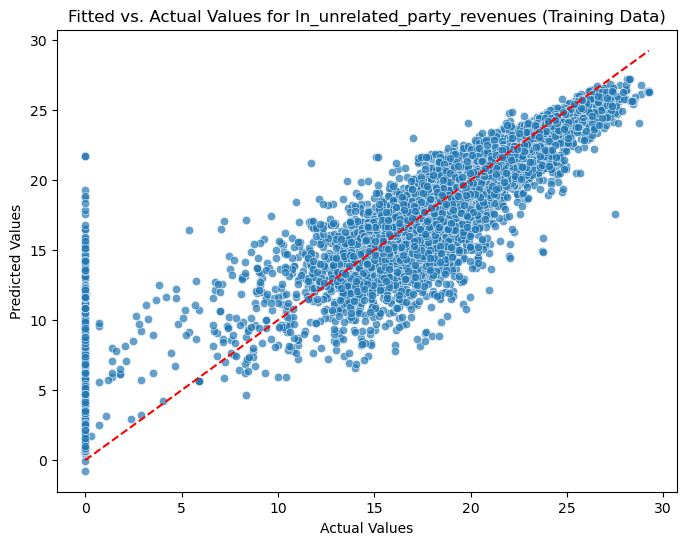

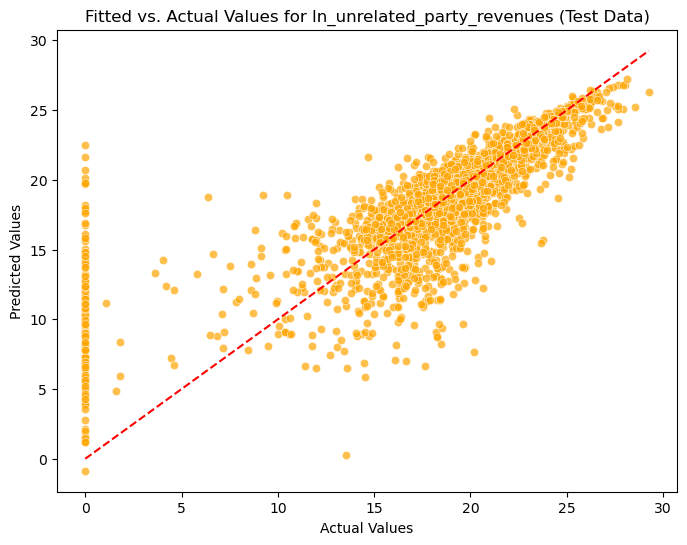

Variable: ln_unrelated_party_revenues
In-sample R² (Training): 0.7990
Out-of-sample R² (Test): 0.6622
----------------------------------------
Processing variable: ln_tangible_assets_except_cash


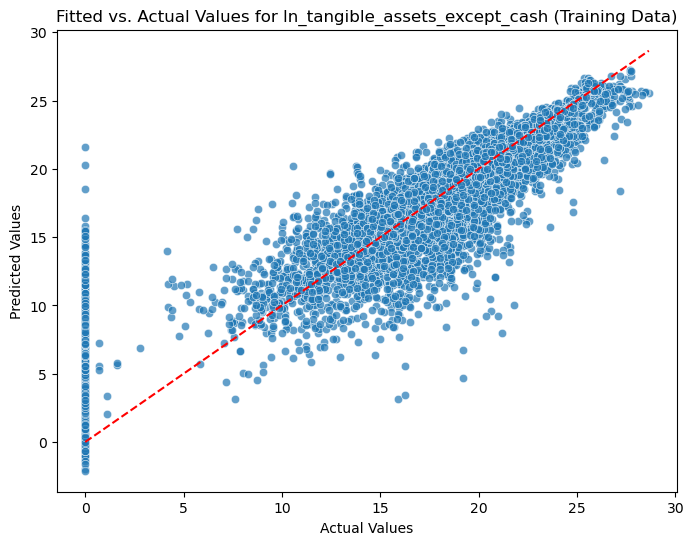

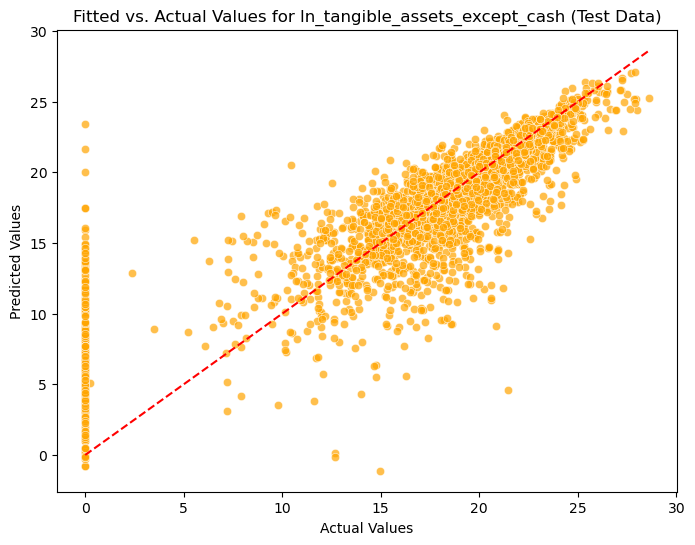

Variable: ln_tangible_assets_except_cash
In-sample R² (Training): 0.8330
Out-of-sample R² (Test): 0.7072
----------------------------------------
Processing variable: ln_stated_capital


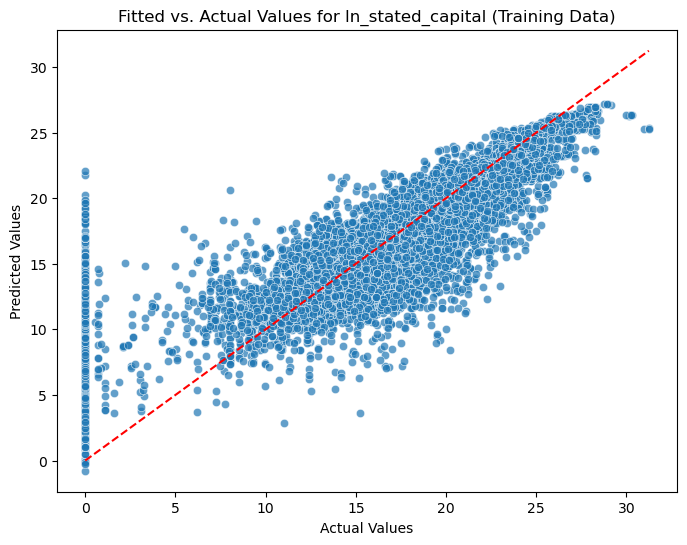

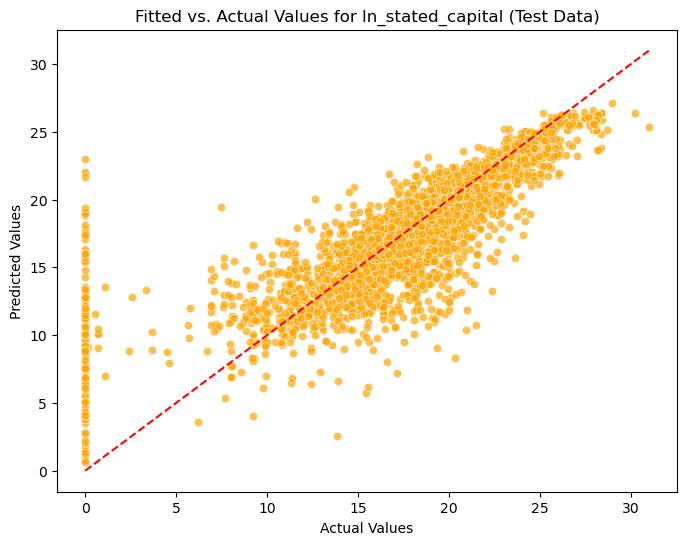

Variable: ln_stated_capital
In-sample R² (Training): 0.7344
Out-of-sample R² (Test): 0.6722
----------------------------------------
Processing variable: ln_total_revenues


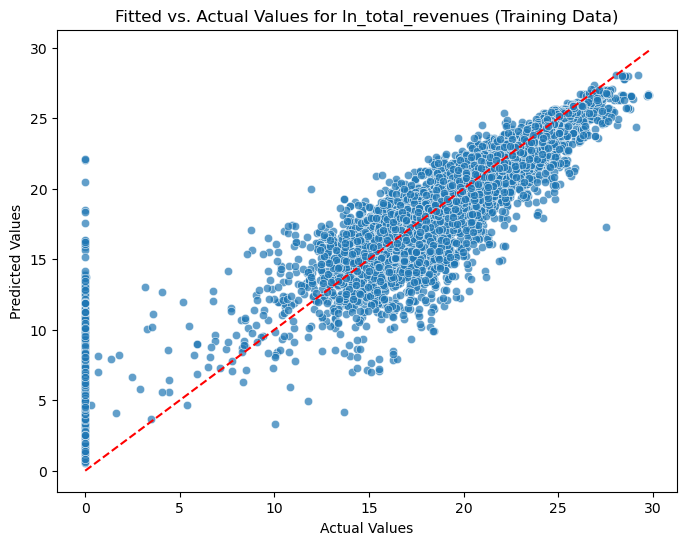

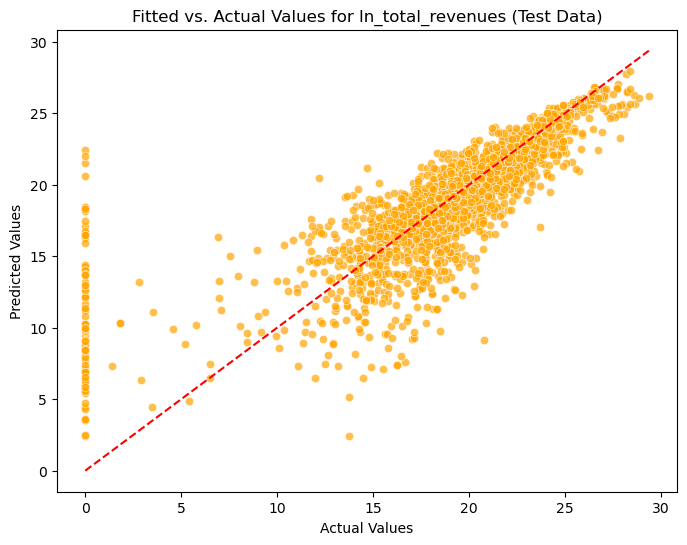

Variable: ln_total_revenues
In-sample R² (Training): 0.8139
Out-of-sample R² (Test): 0.6793
----------------------------------------
Processing variable: ln_related_party_revenues


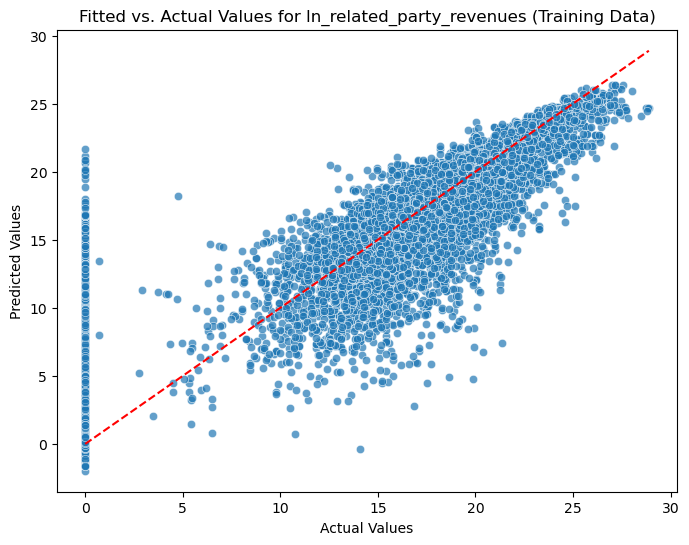

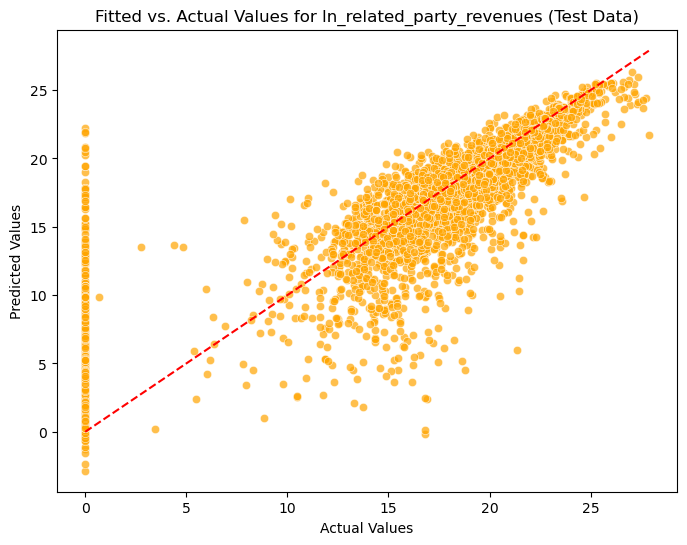

Variable: ln_related_party_revenues
In-sample R² (Training): 0.7855
Out-of-sample R² (Test): 0.6596
----------------------------------------
Processing variable: ln_holding_or_managing_ip


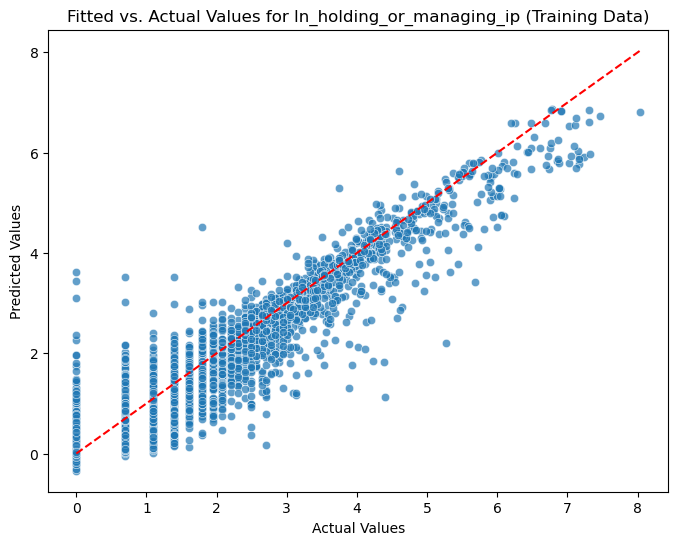

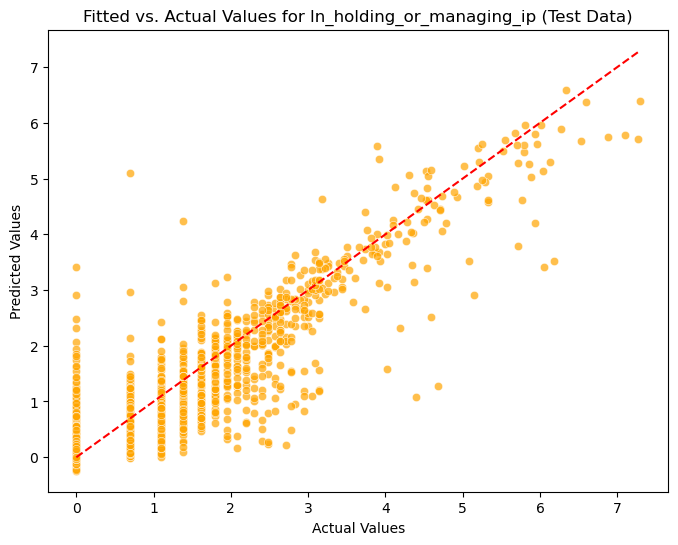

Variable: ln_holding_or_managing_ip
In-sample R² (Training): 0.9118
Out-of-sample R² (Test): 0.8360
----------------------------------------


In [71]:
r2_results = r2_results = evaluate_foreign_predictions(filled_foreign_data,metaparameters,target_variables,predictor_variables_foreign)

#### 3.4 Make sure that predicted values for individual countries add up to a known total

#### 3.4.1 Define scaling for continents

Define region country mapping

In [72]:
region_countries_mapping = {
    'A': [  # America
        'ATG', 'ARG', 'BHS', 'BRB', 'BLZ', 'BOL', 'BRA', 'CAN', 'CHL', 'COL',
        'CRI', 'CUB', 'DMA', 'DOM', 'ECU', 'SLV', 'GRD', 'GTM', 'GUY', 'HTI',
        'HND', 'JAM', 'MEX', 'NIC', 'PAN', 'PRY', 'PER', 'KNA', 'LCA', 'VCT',
        'SUR', 'TTO', 'USA', 'URY', 'VEN'
        # Add or remove countries as needed
    ],
    'E': [  # Europe
        'ALB', 'AND', 'AUT', 'BLR', 'BEL', 'BIH', 'BGR', 'HRV', 'CYP', 'CZE',
        'DNK', 'EST', 'FIN', 'FRA', 'DEU', 'GRC', 'HUN', 'ISL', 'IRL', 'ITA',
        'LVA', 'LIE', 'LTU', 'LUX', 'MLT', 'MDA', 'MCO', 'MNE', 'NLD', 'MKD',
        'NOR', 'POL', 'PRT', 'ROU', 'RUS', 'SMR', 'SRB', 'SVK', 'SVN', 'ESP',
        'SWE', 'CHE', 'UKR', 'GBR', 'VAT'
        # Add or remove countries as needed
    ],
    'F': [  # Africa
        'DZA', 'AGO', 'BEN', 'BWA', 'BFA', 'BDI', 'CPV', 'CMR', 'CAF', 'TCD',
        'COM', 'COD', 'COG', 'CIV', 'DJI', 'EGY', 'GNQ', 'ERI', 'SWZ', 'ETH',
        'GAB', 'GMB', 'GHA', 'GIN', 'GNB', 'KEN', 'LSO', 'LBR', 'LBY', 'MDG',
        'MWI', 'MLI', 'MRT', 'MUS', 'MAR', 'MOZ', 'NAM', 'NER', 'NGA', 'RWA',
        'STP', 'SEN', 'SYC', 'SLE', 'SOM', 'ZAF', 'SSD', 'SDN', 'TZA', 'TGO',
        'TUN', 'UGA', 'ZMB', 'ZWE'
        # Add or remove countries as needed
    ],
    'S': [  # Asia
        'AFG', 'ARM', 'AZE', 'BHR', 'BGD', 'BTN', 'BRN', 'KHM', 'CHN', 'GEO',
        'IND', 'IDN', 'IRN', 'IRQ', 'ISR', 'JPN', 'JOR', 'KAZ', 'KWT', 'KGZ',
        'LAO', 'LBN', 'MYS', 'MDV', 'MNG', 'MMR', 'NPL', 'PRK', 'OMN', 'PAK',
        'PSE', 'PHL', 'QAT', 'SAU', 'SGP', 'KOR', 'LKA', 'SYR', 'TWN', 'TJK',
        'THA', 'TLS', 'TUR', 'TKM', 'ARE', 'UZB', 'VNM', 'YEM'
        # Add or remove countries as needed
    ],
}


Define variables to be scaled. These are always the same variables as target_variables but the non-logged version

In [73]:
scaling_variables = [var.replace('ln_', '', 1) for var in target_variables]

Specificy function for scaling

In [74]:
def scale_predicted_values_continents(filled_foreign_data, variables, region_countries_mapping):
    """
    Scales the predicted values of multiple variables for individual countries within aggregated regions,
    so that they sum up to the known values for the aggregated regions.

    Parameters:
    - filled_foreign_data: DataFrame containing the data, including the predicted values.
    - variables: List of variables to scale (e.g., ['n_employees', 'unrelated_party_revenues', ...]).
    - region_countries_mapping: A dictionary mapping aggregated regions to lists of country codes.

    Returns:
    - DataFrame with scaled predicted values for individual countries.
    """
    df = filled_foreign_data.copy()

    # Initialize a list to keep track of iso_parents where scaling was done
    iso_parents_scaled = []

    # For each aggregated region
    for region, countries in region_countries_mapping.items():
        print(f"Processing region: {region}")

        # For each iso_parent that has data for the aggregated region
        iso_parents = df[df['iso_partner'] == region]['iso_parent'].unique()
        for iso_parent in iso_parents:
            # Record whether scaling was done for this iso_parent
            scaling_done = False

            # For each variable
            for variable in variables:
                predicted_var = f'fitted_{variable}'
                scaled_var = f'scaled_{predicted_var}'

                if predicted_var not in df.columns:
                    print(f"Predicted variable '{predicted_var}' not found in DataFrame. Skipping variable '{variable}'.")
                    continue  # Skip to the next variable

                # Initialize the scaled variable column with NaN if not already initialized
                if scaled_var not in df.columns:
                    df[scaled_var] = np.nan

                # Get the known value for the aggregated region
                mask_region = (df['iso_partner'] == region) & (df['iso_parent'] == iso_parent)
                known_values = df.loc[mask_region, variable].values
                if len(known_values) == 0:
                    continue
                known_value = known_values[0]

                # Check if known_value is NaN
                if pd.isna(known_value):
                    continue  # Skip if known_value is NaN

                # Get the predicted values for individual countries within the region
                mask_countries = df['iso_partner'].isin(countries) & (df['iso_parent'] == iso_parent)
                predicted_values = df.loc[mask_countries, predicted_var]

                if predicted_values.empty:
                    continue

                sum_predicted = predicted_values.sum()

                # Check if sum_predicted is NaN or zero
                if pd.isna(sum_predicted) or sum_predicted == 0:
                    scaling_factor = np.nan
                else:
                    scaling_factor = known_value / sum_predicted

                # Check if scaling_factor is NaN
                if pd.isna(scaling_factor):
                    continue  # Skip scaling if scaling_factor is NaN

                # Scale the predicted values
                df.loc[mask_countries, scaled_var] = predicted_values * scaling_factor

                scaling_done = True  # Mark that scaling was done for this iso_parent

                # Only print if scaling_factor is not NaN
                print(f"  Scaled '{variable}' for iso_parent '{iso_parent}' in region '{region}' with scaling factor {scaling_factor:.4f}")

            # Record the iso_parent if scaling was done for any variable
            if scaling_done:
                iso_parents_scaled.append(iso_parent)

    # Optionally, print the iso_parents where scaling was done
    unique_iso_parents_scaled = list(set(iso_parents_scaled))
    print("\nScaling was performed for the following iso_parents:")
    for ip in unique_iso_parents_scaled:
        print(ip)

    return df

#### 3.4.2 Verify scaling according to continents

In [75]:
def verify_scaling_continents(df, variables, region_countries_mapping):
    for variable in variables:
        scaled_var = f'scaled_fitted_{variable}'
        print(f"\nVerifying scaling for variable: {variable}")
        for region, countries in region_countries_mapping.items():
            iso_parents = df[df['iso_partner'] == region]['iso_parent'].unique()
            for iso_parent in iso_parents:
                known_values = df.loc[
                    (df['iso_partner'] == region) & (df['iso_parent'] == iso_parent),
                    variable
                ].values
                if len(known_values) == 0:
                    continue
                known_value = known_values[0]
                
                # Check if known_value is missing
                if pd.isna(known_value):
                    continue  # Skip if known_value is NaN or missing
                
                sum_scaled = df.loc[
                    df['iso_partner'].isin(countries) & (df['iso_parent'] == iso_parent),
                    scaled_var
                ].sum()
                
                if pd.isna(sum_scaled):
                    continue  # Skip if sum_scaled is NaN or missing
                
                print(f"iso_parent: {iso_parent}, Region: {region}, Known Value: {known_value}, Sum of Scaled Predictions: {sum_scaled}")

In [76]:
scaled_data_continents = scale_predicted_values_continents(filled_foreign_data, scaling_variables, region_countries_mapping)

Processing region: A
  Scaled 'profit_loss_before_income_tax_corrected' for iso_parent 'AUT' in region 'A' with scaling factor 0.3614
  Scaled 'n_employees' for iso_parent 'AUT' in region 'A' with scaling factor 0.0801
  Scaled 'unrelated_party_revenues' for iso_parent 'AUT' in region 'A' with scaling factor 0.2535
  Scaled 'tangible_assets_except_cash' for iso_parent 'AUT' in region 'A' with scaling factor 0.1859
  Scaled 'stated_capital' for iso_parent 'AUT' in region 'A' with scaling factor 0.1059
  Scaled 'total_revenues' for iso_parent 'AUT' in region 'A' with scaling factor 0.1791
  Scaled 'related_party_revenues' for iso_parent 'AUT' in region 'A' with scaling factor 0.2231
  Scaled 'profit_loss_before_income_tax_corrected' for iso_parent 'JPN' in region 'A' with scaling factor 0.4893
  Scaled 'n_employees' for iso_parent 'JPN' in region 'A' with scaling factor 0.0208
  Scaled 'unrelated_party_revenues' for iso_parent 'JPN' in region 'A' with scaling factor 0.0289
  Scaled 'tang

In [77]:
verify_scaling_continents(scaled_data_continents, scaling_variables, region_countries_mapping)


Verifying scaling for variable: profit_loss_before_income_tax_corrected
iso_parent: AUT, Region: A, Known Value: 2121421715.0, Sum of Scaled Predictions: 2121421715.0000005
iso_parent: JPN, Region: A, Known Value: 8416481713.0, Sum of Scaled Predictions: 8416481713.000002
iso_parent: NOR, Region: A, Known Value: -3147801000.0, Sum of Scaled Predictions: -3147801000.0
iso_parent: SWE, Region: A, Known Value: 7588472209.0, Sum of Scaled Predictions: 7588472209.0
iso_parent: AUT, Region: E, Known Value: 11104466591.0, Sum of Scaled Predictions: 11104466590.999998
iso_parent: NOR, Region: E, Known Value: 6807796000.0, Sum of Scaled Predictions: 6807796000.0
iso_parent: SWE, Region: E, Known Value: 13977920311.0, Sum of Scaled Predictions: 13977920310.999998
iso_parent: AUT, Region: F, Known Value: 358049873.2, Sum of Scaled Predictions: 358049873.2
iso_parent: CAN, Region: F, Known Value: 768275000.0, Sum of Scaled Predictions: 768275000.0
iso_parent: NOR, Region: F, Known Value: -1708030

#### 3.4.3 Define scaling for "other" countries (i.e. countries in a continent where other values are given on a country by country basis but some countries are subsumed under "Other")

In [78]:
region_other_mapping = {
    'A': 'A_O',  # "Other America"
    'E': 'E_O',  # "Other Europe"
    'F': 'F_O',  # "Other Africa"
    'S': 'S_O',  # "Other Asia"
}

In [79]:
def scale_other_predicted_values(filled_foreign_data, variables, region_countries_mapping, region_other_mapping):
    """
    Scales the predicted values of variables for "Other" groups in regions for each iso_parent.

    Parameters:
    - filled_foreign_data: DataFrame containing the data, including predicted values.
    - variables: List of variables to scale.
    - region_countries_mapping: Dictionary mapping regions to lists of country codes.
    - region_other_mapping: Dictionary mapping regions to their "Other" codes.

    Returns:
    - DataFrame with scaled predicted values for "Other" countries.
    """
    df = filled_foreign_data.copy()
    
    # Initialize scaled variable columns
    for variable in variables:
        scaled_var = f'scaled_fitted_{variable}'
        if scaled_var not in df.columns:
            df[scaled_var] = np.nan
    
    # List to keep track of iso_parents where scaling was done
    iso_parents_scaled = []
    
    # For each region
    for region_code, countries in region_countries_mapping.items():
        other_code = region_other_mapping.get(region_code)
        if not other_code:
            continue  # Skip if no "Other" code defined for the region
        
        print(f"Processing region: {region_code} (Other code: {other_code})")
        
        # Find iso_parents that have "Other" data for this region
        iso_parents = df[df['iso_partner'] == other_code]['iso_parent'].unique()
        for iso_parent in iso_parents:
            # For each variable
            scaling_done = False
            for variable in variables:
                predicted_var = f'fitted_{variable}'
                scaled_var = f'scaled_fitted_{variable}'
                
                # Ensure the predicted variable exists
                if predicted_var not in df.columns:
                    print(f"Predicted variable '{predicted_var}' not found. Skipping variable '{variable}'.")
                    continue
                
                # Get the known "Other" value
                mask_other = (df['iso_partner'] == other_code) & (df['iso_parent'] == iso_parent)
                known_values = df.loc[mask_other, variable].values
                if len(known_values) == 0:
                    continue
                known_other_value = known_values[0]
                
                # Check if known_other_value is NaN
                if pd.isna(known_other_value):
                    continue  # Skip if known_other_value is NaN

                # Identify countries in the region where the iso_parent does NOT have individual data
                mask_region_countries = (df['iso_partner'].isin(countries)) & (df['iso_parent'] == iso_parent)
                mask_missing_variable = df[variable].isna()
                mask_countries_in_other = mask_region_countries & mask_missing_variable
                
                # Get predicted values for these countries
                predicted_values = df.loc[mask_countries_in_other, predicted_var]
                
                if predicted_values.empty:
                    continue
                
                sum_predicted = predicted_values.sum()
                
                # Check if sum_predicted is NaN or zero
                if pd.isna(sum_predicted) or sum_predicted == 0:
                    scaling_factor = np.nan
                else:
                    scaling_factor = known_other_value / sum_predicted
                
                # Check if scaling_factor is NaN
                if pd.isna(scaling_factor):
                    continue  # Skip scaling if scaling_factor is NaN

                # Scale the predicted values
                df.loc[mask_countries_in_other, scaled_var] = predicted_values * scaling_factor
                
                scaling_done = True
                
                # Only print if scaling_factor is not NaN
                print(f"  Scaled '{variable}' for iso_parent '{iso_parent}' in 'Other' of region '{region_code}' with scaling factor {scaling_factor:.4f}")
            
            if scaling_done:
                iso_parents_scaled.append(iso_parent)
    
    # Optionally, print the iso_parents where scaling was done
    unique_iso_parents_scaled = list(set(iso_parents_scaled))
    print("\nScaling for 'Other' was performed for the following iso_parents:")
    for ip in unique_iso_parents_scaled:
        print(ip)
    
    return df


In [80]:
def verify_other_scaling(df, variables, region_countries_mapping, region_other_mapping):
    for variable in variables:
        scaled_var = f'scaled_fitted_{variable}'
        print(f"\nVerifying scaling for 'Other' variable: {variable}")
        for region_code, countries in region_countries_mapping.items():
            other_code = region_other_mapping.get(region_code)
            if not other_code:
                continue
            iso_parents = df[df['iso_partner'] == other_code]['iso_parent'].unique()
            for iso_parent in iso_parents:
                # Known "Other" value
                known_other_value = df.loc[
                    (df['iso_partner'] == other_code) & (df['iso_parent'] == iso_parent),
                    variable
                ].values
                if len(known_other_value) == 0:
                    continue
                known_other_value = known_other_value[0]
                
                # Sum of scaled predicted values
                mask_region_countries = (df['iso_partner'].isin(countries)) & (df['iso_parent'] == iso_parent)
                mask_missing_variable = df[variable].isna()
                mask_countries_in_other = mask_region_countries & mask_missing_variable
                sum_scaled = df.loc[mask_countries_in_other, scaled_var].sum()
                
                if pd.isna(sum_scaled):
                    continue
                
                print(f"iso_parent: {iso_parent}, Region: {region_code}, Known 'Other' Value: {known_other_value}, Sum of Scaled Predictions: {sum_scaled}")


In [81]:
scaled_data_other = scale_other_predicted_values(
    filled_foreign_data=filled_foreign_data,
    variables=scaling_variables,
    region_countries_mapping=region_countries_mapping,
    region_other_mapping=region_other_mapping
)

Processing region: A (Other code: A_O)
  Scaled 'profit_loss_before_income_tax_corrected' for iso_parent 'AUS' in 'Other' of region 'A' with scaling factor 3.0026
  Scaled 'n_employees' for iso_parent 'AUS' in 'Other' of region 'A' with scaling factor 0.0409
  Scaled 'unrelated_party_revenues' for iso_parent 'AUS' in 'Other' of region 'A' with scaling factor 0.0285
  Scaled 'tangible_assets_except_cash' for iso_parent 'AUS' in 'Other' of region 'A' with scaling factor 0.0273
  Scaled 'stated_capital' for iso_parent 'AUS' in 'Other' of region 'A' with scaling factor 0.2144
  Scaled 'total_revenues' for iso_parent 'AUS' in 'Other' of region 'A' with scaling factor 0.0141
  Scaled 'related_party_revenues' for iso_parent 'AUS' in 'Other' of region 'A' with scaling factor 0.0423
  Scaled 'profit_loss_before_income_tax_corrected' for iso_parent 'BEL' in 'Other' of region 'A' with scaling factor 1.2389
  Scaled 'n_employees' for iso_parent 'BEL' in 'Other' of region 'A' with scaling factor 0.

In [ ]:
verify_other_scaling(scaled_data_other,
                     variables=scaling_variables,
                     region_countries_mapping=region_countries_mapping,
                     region_other_mapping=region_other_mapping)

### 4. Multiple imputation
- Now, all the previously defined steps are combined to:
    1. Impute missing domestic values
    2. Impute missing foreign values
    3. Make sure that imputed values add up to known totals:
        - For aggregated continent data
        - for aggregated "other" continent data
        - for aggregated "other" / "rest of the world" countries
- This imputation is ran n times to generate a range of potential dataset with slightly different imputed values. Later (in notebook 3_estimate_profit_shifting), we will calculate misalignment for each of these datasets and take the median value.


#### 4.1 Illustrate imputation process for one sample

In [83]:
# Step 1: Split the DataFrame
domestic_mask = cbcr_imputation_sample['iso_parent'] == cbcr_imputation_sample['iso_partner']
foreign_mask = cbcr_imputation_sample['iso_parent'] != cbcr_imputation_sample['iso_partner']

cbcr_domestic = cbcr_imputation_sample[domestic_mask].copy()
cbcr_foreign = cbcr_imputation_sample[foreign_mask].copy()

# Step 2: Impute Domestic Values
cbcr_domestic_imputed = predict_domestic_values(cbcr_domestic)

# Step 3: Impute Foreign Values
cbcr_foreign_imputed = predict_foreign_values(cbcr_foreign)

# Step 4a: Scaling for aggregated continent data
cbcr_foreign_scaled = scale_predicted_values_continents(
    filled_foreign_data=cbcr_foreign_imputed,
    variables=target_variables,
    region_countries_mapping=region_countries_mapping
)

# Step 4b: Scaling for "Other" continent data
cbcr_foreign_scaled = scale_other_predicted_values(
    filled_foreign_data=cbcr_foreign_scaled,
    variables=target_variables,
    region_countries_mapping=region_countries_mapping,
    region_other_mapping=region_other_mapping
)

# Step 5: Combine Domestic and Foreign Data
cbcr_with_imputed_values = pd.concat([cbcr_domestic_imputed, cbcr_foreign_scaled], ignore_index=True)

# Step 6: Substitute Variables
for variable in target_variables:
    actual_var = variable
    scaled_var = f'scaled_fitted_{variable}'
    fitted_var = f'fitted_{variable}'

    # Substitute actual variable with scaled variable when scaled variable is not missing
    scaled_not_missing_mask = cbcr_with_imputed_values[scaled_var].notna()
    cbcr_with_imputed_values.loc[scaled_not_missing_mask, actual_var] = cbcr_with_imputed_values.loc[scaled_not_missing_mask, scaled_var]

    # Substitute missing actual variable with fitted variable
    actual_missing_mask = cbcr_with_imputed_values[actual_var].isna()
    cbcr_with_imputed_values.loc[actual_missing_mask, actual_var] = cbcr_with_imputed_values.loc[actual_missing_mask, fitted_var]

# Step 7: Clean Up Auxiliary Columns (Optional)
auxiliary_columns = []
for variable in target_variables:
    auxiliary_columns.extend([f'fitted_{variable}', f'scaled_fitted_{variable}'])

cbcr_with_imputed_values = cbcr_with_imputed_values.drop(columns=auxiliary_columns)


Predicting values for: ln_profit_loss_before_income_tax_corrected
Predicting values for: ln_n_employees
Predicting values for: ln_unrelated_party_revenues
Predicting values for: ln_tangible_assets_except_cash
Predicting values for: ln_stated_capital
Predicting values for: ln_total_revenues
Predicting values for: ln_related_party_revenues
Predicting values for: ln_holding_or_managing_ip
Processing region: A
  Scaled 'ln_profit_loss_before_income_tax_corrected' for iso_parent 'AUT' in region 'A' with scaling factor 0.0083
  Scaled 'ln_n_employees' for iso_parent 'AUT' in region 'A' with scaling factor 0.0089
  Scaled 'ln_unrelated_party_revenues' for iso_parent 'AUT' in region 'A' with scaling factor 0.0065
  Scaled 'ln_tangible_assets_except_cash' for iso_parent 'AUT' in region 'A' with scaling factor 0.0065
  Scaled 'ln_stated_capital' for iso_parent 'AUT' in region 'A' with scaling factor 0.0069
  Scaled 'ln_total_revenues' for iso_parent 'AUT' in region 'A' with scaling factor 0.0063

KeyboardInterrupt: 

### 3.5 Generate and save bootstrapped samples with imputed values

In [24]:
# Define the number of bootstrap samples
n_bootstrap_samples = 1 # Adjust as needed

# Define your target variables and other necessary variables/functions
target_variables = [
    'n_employees',
    'unrelated_party_revenues',
    'profit_loss_before_income_tax_corrected',
    'tangible_assets_except_cash'
]

# Ensure that your functions are defined:
# - predict_domestic_values()
# - predict_foreign_values()
# - scale_predicted_values_continent()
# - scale_other_predicted_values()

# Define the function to process a single bootstrap sample
def process_bootstrap_sample(sample_number):
    print(f"Processing bootstrap sample {sample_number}/{n_bootstrap_samples}")
    
    # Create a bootstrap sample
    bootstrap_sample = cbcr_imputation_sample.sample(
        n=len(cbcr_imputation_sample), 
        replace=True, 
        random_state=sample_number
    ).reset_index(drop=True)
    
    # Split into domestic and foreign data
    domestic_mask = bootstrap_sample['iso_parent'] == bootstrap_sample['iso_partner']
    foreign_mask = bootstrap_sample['iso_parent'] != bootstrap_sample['iso_partner']
    
    cbcr_domestic = bootstrap_sample[domestic_mask].copy()
    cbcr_foreign = bootstrap_sample[foreign_mask].copy()
    
    # Impute missing domestic values
    cbcr_domestic_imputed = predict_domestic_values(cbcr_domestic)
    
    # Impute missing foreign values
    cbcr_foreign_imputed = predict_foreign_values(cbcr_foreign)
    
    # Apply scaling to foreign data
    cbcr_foreign_scaled = scale_predicted_values_continents(
        filled_foreign_data=cbcr_foreign_imputed,
        variables=target_variables,
        region_countries_mapping=region_countries_mapping
    )
    
    cbcr_foreign_scaled = scale_other_predicted_values(
        filled_foreign_data=cbcr_foreign_scaled,
        variables=target_variables,
        region_countries_mapping=region_countries_mapping,
        region_other_mapping=region_other_mapping
    )
    
    # Combine domestic and foreign data
    cbcr_combined = pd.concat([cbcr_domestic_imputed, cbcr_foreign_scaled], ignore_index=True)
    
    # Substitute variables
    for variable in target_variables:
        actual_var = variable
        scaled_var = f'scaled_fitted_{variable}'
        fitted_var = f'fitted_{variable}'

        # Substitute actual variable with scaled variable when scaled variable is not missing
        scaled_not_missing_mask = cbcr_combined[scaled_var].notna()
        cbcr_combined.loc[scaled_not_missing_mask, actual_var] = cbcr_combined.loc[scaled_not_missing_mask, scaled_var]

        # Substitute missing actual variable with fitted variable
        actual_missing_mask = cbcr_combined[actual_var].isna()
        cbcr_combined.loc[actual_missing_mask, actual_var] = cbcr_combined.loc[actual_missing_mask, fitted_var]
    
    # Drop auxiliary columns
    auxiliary_columns = []
    for variable in target_variables:
        auxiliary_columns.extend([f'fitted_{variable}', f'scaled_fitted_{variable}'])
    
    cbcr_combined = cbcr_combined.drop(columns=auxiliary_columns)
    
    # Add sample number column
    cbcr_combined['sample_number'] = sample_number
    
    # Return the processed sample
    return cbcr_combined

# Use Parallel to process samples in parallel
bootstrap_samples = Parallel(n_jobs=-1)(
    delayed(process_bootstrap_sample)(i) for i in range(1, n_bootstrap_samples + 1)
)

# Combine all bootstrap samples
cbcr_bootstrap_combined = pd.concat(bootstrap_samples, ignore_index=True)

# Export to CSV
cbcr_bootstrap_combined.to_csv('cbcr_bootstrap_samples.csv', index=False)

print("Bootstrap processing complete. Data saved to 'cbcr_bootstrap_samples.csv'.")

1: (390, 10)
(390, 10)
ln_profit_loss_before_income_tax_corrected 0.2641070427481751
ln_n_employees 0.9319132709887357
ln_unrelated_party_revenues 0.9036990136478503
ln_tangible_assets_except_cash 0.7945464342644805
ln_stated_capital 0.780301284026027
ln_total_revenues 0.917318676561771
ln_related_party_revenues 0.6708786466885189
ln_holding_or_managing_ip 0.7301124879023333


c:\Users\AlisonSchultz\anaconda3\envs\sotj_profit_shifting_estimates\Lib\site-packages\sklearn\impute\_iterative.py:796: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient
Variable,,,,,,,,
ln_gdp_current_usd,2.211378,1.554960,1.398214,2.103174,3.203791,1.644324,1.818074,-0.113901
ln_population,1.265112,-0.417246,-0.256054,-0.913193,-1.633583,-0.604985,-0.489362,0.164055
ln_gvt_health_expenditure,-1.935215,-0.046215,-0.501107,-0.595220,-1.069754,-0.402725,-0.396592,0.309165
etr_foreign_corrected,-6.315969,0.354968,4.186902,2.224279,-1.203654,2.013493,-1.897149,1.224603
cit,8.986660,3.351398,-0.754005,-0.105328,2.514328,-0.114800,2.708096,-1.323461
ln_n_companies_orbis,2.663305,0.066187,0.379101,0.665302,0.447972,0.515766,-0.040295,-0.195965
ln_turnover_orbis,-2.356942,0.077617,0.120539,0.017666,0.254390,0.106276,0.413524,0.726489
ln_n_employees_orbis,0.441228,0.016906,0.127223,0.000415,-0.024711,0.034668,-0.037071,-0.032787
ln_wage_monthly,2.292878,-0.526526,0.065542,-0.843178,-0.940757,-0.319378,-0.064585,0.353909


dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_in

c:\Users\AlisonSchultz\anaconda3\envs\sotj_profit_shifting_estimates\Lib\site-packages\sklearn\impute\_iterative.py:796: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


...

,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient
Variable,,,,,,,,
ln_gdp_current_usd,0.234825,1.236276,1.128934,2.298628,2.556585,1.475725,2.737506,0.435975
ln_population,1.993335,-0.159797,-0.115885,-0.603898,-0.958442,-0.400607,-0.663022,-0.503486
ln_gvt_health_expenditure,-0.383094,-0.049136,-0.377348,-0.793914,-1.179645,-0.299702,-0.832386,0.669024
etr_foreign_corrected,11.702982,1.031485,3.627817,0.486741,0.493954,0.853969,-2.177028,-0.389964
cit,-13.041561,2.285685,-0.617550,1.246167,1.401523,1.314275,4.273568,-2.954092
ln_n_companies_orbis,1.752042,0.224246,0.380390,0.322445,-0.136838,0.358767,-0.364133,-0.083058
ln_turnover_orbis,-1.896567,-0.072798,0.176232,0.061953,0.648639,0.114780,0.372045,0.608520
ln_n_employees_orbis,0.577662,0.098324,0.050841,-0.014008,0.174419,0.037754,-0.049056,-0.083222
ln_wage_monthly,2.379989,-0.325828,0.102844,-0.323624,-0.571914,-0.130425,0.108959,-0.339817


dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_in

c:\Users\AlisonSchultz\anaconda3\envs\sotj_profit_shifting_estimates\Lib\site-packages\sklearn\impute\_iterative.py:796: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient
Variable,,,,,,,,
ln_gdp_current_usd,4.679829,1.645628,1.174091,1.911857,3.277278,1.564480,3.184433,0.326406
ln_population,-0.556214,-0.160709,-0.243870,-0.666349,-1.707783,-0.466652,-1.351472,-0.290665
ln_gvt_health_expenditure,-2.054925,-0.314645,-0.215861,-0.638426,-1.003055,-0.475636,-0.915263,0.393930
etr_foreign_corrected,3.623656,1.058690,3.065036,1.798761,-1.489418,2.131726,0.231798,1.025961
cit,-5.642499,2.434542,-0.721763,0.164738,1.702016,1.473678,2.287389,-0.867690
ln_n_companies_orbis,-0.486219,0.334857,0.882779,0.547198,-0.124590,0.210370,-0.127454,-0.106142
ln_turnover_orbis,-0.401579,-0.315631,-0.229689,0.021154,0.590773,0.299688,0.466405,0.649024
ln_n_employees_orbis,0.601267,0.184847,0.083416,0.018556,0.049147,0.033713,-0.045672,-0.054270
ln_wage_monthly,0.559357,-0.121341,-0.043882,-0.570023,-1.175003,-0.155826,-0.535094,-0.028685


dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_in

### Combine imputed data with other data

In [25]:
def num(x):
    """
    Convert numbers of strings to floats
    """
    try:
        return float(x)
    except:
        return np.nan

In [26]:
cbcr_with_imputeded_data = pd.read_csv(f'{data_intermediate}cbcr_bootstrapped_imputation.csv',sep="\t").reset_index(drop=True)

#cbcr_main = cbcr_main.drop_duplicates()
for col in list(cbcr_with_imputeded_data.columns)[2:]:
    cbcr_with_imputeded_data[col] = cbcr_with_imputeded_data[col].apply(num)
    
#cbcr_main = cbcr_main.dropna()
columns_from_original_data = ['iso_parent','iso_partner','year',
            'wage_monthly','gdp_current_usd','gvt_health_expenditure',
            'cit','etr_foreign_corrected','population', 'etr_domestic_corrected', 'etr_average_corrected',
            'region_tjn', 'ukt']
cbcr_with_imputeded_data = cbcr_with_imputeded_data.merge(cbcr_main_no_imputation_allsubgroupsonly[columns_from_original_data],
            on=['iso_partner', 'year'], how='outer')
cbcr_with_imputeded_data['payroll'] = cbcr_with_imputeded_data['n_employees'] * cbcr_with_imputeded_data['wage_monthly'] * 12 
cbcr_with_imputeded_data.to_csv(f'{data_final}/cbcr_with_imputed_data.csv')